In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)


In [2]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#%cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"
%cd "/content/drive/MyDrive/GCI_World/Final Assignment-20260530T125834Z-3-001/Final Assignment"

/content/drive/MyDrive/GCI_World/Final Assignment-20260530T125834Z-3-001/Final Assignment


In [4]:
# loading source table
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/GCI_World/Final Assignment-20260530T125834Z-3-001/Final Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/GCI_World/Final Assignment-20260530T125834Z-3-001/Final Assignment/telecom/Record.csv


In [5]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [6]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


Inspection of the Data to ascertain the necessity for Data Cleaning before EDA


In [7]:
# Dataset overview
df.info()

# Statistical summary
df.describe()

# Check column names
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     10

['rev_Mean',
 'mou_Mean',
 'totmrc_Mean',
 'da_Mean',
 'ovrmou_Mean',
 'ovrrev_Mean',
 'vceovr_Mean',
 'datovr_Mean',
 'roam_Mean',
 'change_mou',
 'change_rev',
 'drop_vce_Mean',
 'drop_dat_Mean',
 'blck_vce_Mean',
 'blck_dat_Mean',
 'unan_vce_Mean',
 'unan_dat_Mean',
 'plcd_vce_Mean',
 'plcd_dat_Mean',
 'recv_vce_Mean',
 'recv_sms_Mean',
 'comp_vce_Mean',
 'comp_dat_Mean',
 'custcare_Mean',
 'ccrndmou_Mean',
 'cc_mou_Mean',
 'inonemin_Mean',
 'threeway_Mean',
 'mou_cvce_Mean',
 'mou_cdat_Mean',
 'mou_rvce_Mean',
 'owylis_vce_Mean',
 'mouowylisv_Mean',
 'iwylis_vce_Mean',
 'mouiwylisv_Mean',
 'peak_vce_Mean',
 'peak_dat_Mean',
 'mou_peav_Mean',
 'mou_pead_Mean',
 'opk_vce_Mean',
 'opk_dat_Mean',
 'mou_opkv_Mean',
 'mou_opkd_Mean',
 'drop_blk_Mean',
 'attempt_Mean',
 'complete_Mean',
 'callfwdv_Mean',
 'callwait_Mean',
 'churn',
 'months',
 'Customer_ID',
 'uniqsubs',
 'actvsubs',
 'new_cell',
 'crclscod',
 'asl_flag',
 'totcalls',
 'totmou',
 'totrev',
 'adjrev',
 'adjmou',
 'adjqty',

In [8]:
# Checking for missing values
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
numbcars,49366
dwllsize,38308
HHstatin,37923
ownrent,33706
dwlltype,31909
lor,30190
income,25436
adults,23019
infobase,22079
hnd_webcap,10189


In [9]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
numbcars,49.366
dwllsize,38.308
HHstatin,37.923
ownrent,33.706
dwlltype,31.909
...,...
opk_dat_Mean,0.000
opk_vce_Mean,0.000
mou_pead_Mean,0.000
mou_peav_Mean,0.000


In [10]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Understanding the target variable
df['churn'].value_counts()

df['churn'].value_counts(normalize=True)*100

missing_pct = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
missing_pct[missing_pct > 0].head(20)

df[['churn','totrev','months']].describe()

,churn,totrev,months
count,100000.000000,100000.000000,100000.000000
mean,0.495620,1031.924988,18.833990
std,0.499983,852.907511,9.655794
min,0.000000,3.650000,6.000000
25%,0.000000,518.980000,11.000000
50%,0.000000,804.530000,16.000000
75%,1.000000,1263.767500,24.000000
max,1.000000,27321.500000,61.000000


In [12]:
df['churn'].value_counts()

missing_pct[missing_pct > 0]

df.groupby('churn')[['months','totrev']].mean()

,months,totrev
churn,,
0,18.633074,1034.475849
1,19.038457,1029.329041


Identifying Churn drivers


In [13]:
corr_with_churn = (
    df.select_dtypes(include=['int64','float64'])
      .corr()['churn']
      .sort_values(key=abs, ascending=False)
)

corr_with_churn.head(20)

,churn
churn,1.000000
eqpdays,0.112691
hnd_price,-0.103184
totmrc_Mean,-0.068558
mou_Mean,-0.057027
mou_cvce_Mean,-0.052042
complete_Mean,-0.051740
comp_vce_Mean,-0.051574
avg3mou,-0.049546
mou_opkv_Mean,-0.048896


In [14]:
# Service quality
service_cols = [
    'drop_vce_Mean',
    'blck_vce_Mean',
    'drop_blk_Mean',
    'custcare_Mean',
    'callwait_Mean'
]

df.groupby('churn')[service_cols].mean()

,drop_vce_Mean,blck_vce_Mean,drop_blk_Mean,custcare_Mean,callwait_Mean
churn,,,,,
0,6.090553,4.118370,10.286563,1.982599,1.947890
1,5.817222,3.925776,9.797752,1.595688,1.615051


In [15]:
# Checking for device var
df.groupby('churn')[['hnd_price','eqpdays']].mean()

,hnd_price,eqpdays
churn,,
0,108.129344,363.280925
1,95.539523,421.089524


**Key Insight #1: Device Age Is the Strongest Churn Signal**







Customers who churn tend to:

Have older devices (+58 extra days on average)
Own cheaper devices

"Customers with aging or lower-value handsets are more likely to leave the network, potentially because competitors offer better device upgrade incentives".

**Key Insight #2: Service Quality Is Probably NOT the Main Driver**

Churners actually report fewer service issues and fewer customer-care interactions.

**Key Insight #3: High Usage Customers Tend to Stay**

The more customers use the service, the less likely they are to leave.

High engagement = lower churn.

In [16]:
missing_pct = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

,0
numbcars,49.366
dwllsize,38.308
HHstatin,37.923
ownrent,33.706
dwlltype,31.909
lor,30.190
income,25.436
adults,23.019
infobase,22.079
hnd_webcap,10.189


In [17]:
top_features = [
    'eqpdays',
    'hnd_price',
    'mou_Mean',
    'totmrc_Mean',
    'avg3mou'
]

df.groupby('churn')[top_features].mean()

,eqpdays,hnd_price,mou_Mean,totmrc_Mean,avg3mou
churn,,,,,
0,363.280925,108.129344,543.206895,47.782378,545.850073
1,421.089524,95.539523,483.306417,44.543091,492.969109


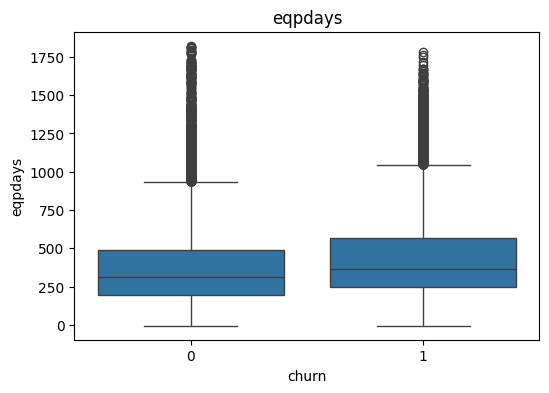

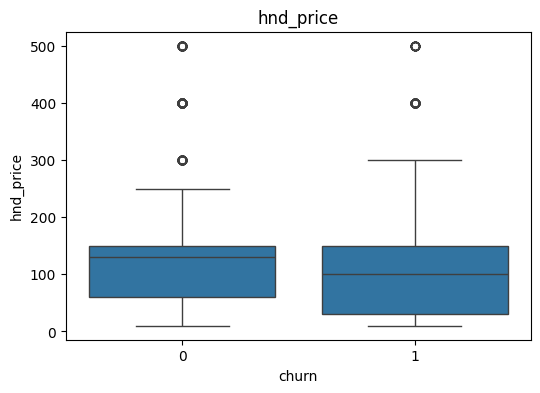

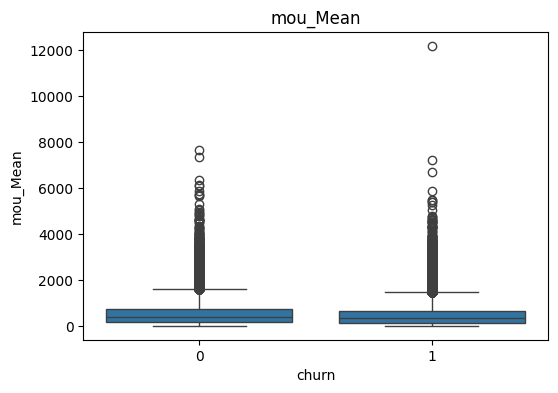

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['eqpdays', 'hnd_price', 'mou_Mean']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(col)
    plt.show()

# Business Problem

The telecom company has a churn rate of approximately 49.6% i.e. Out of every 100 customers acquired, Nearly 50 leave.




Implications:
customer loss,
revenue leakage,
increased acquisition costs.

**Feature Engineering**: Missing value handling,
One-hot encoding,
Column removal.


In [19]:
# Remove high-missing columns
drop_cols = [
    'Customer_ID',
    'numbcars',
    'dwllsize',
    'HHstatin',
    'ownrent',
    'dwlltype',
    'lor'
]

df_model = df.drop(columns=drop_cols)

In [20]:
# Separate target
X = df_model.drop('churn', axis=1)
y = df_model['churn']

In [21]:
# Numeric and Categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numeric: 75
Categorical: 17


In [22]:
# Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [23]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Baseline Model - Logistic Regression (For Interpretability)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
       'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou',
       'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean',
       'blck_dat_Mean', 'unan...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
       'dualband', 'refurb_new', 'hnd_webcap', 'marital', 'infobase', 'ethnic',
       'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [25]:
# lr Model evaluation
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.5783
Precision: 0.5773012552301255
Recall: 0.5567998385794996
F1: 0.5668652423993427
ROC-AUC: 0.6053639693857893


In [26]:
# RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
       'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou',
       'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean',
       'blck_dat_Mean', 'unan...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
       'dualband', 'refurb_new', 'hnd_webcap', 'marital', 'infobase', 'ethnic',
       'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [27]:
# Rf model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.61135
Precision: 0.599442119944212
Recall: 0.6504237288135594
F1: 0.6238931630134997
ROC-AUC: 0.6640790262797951


In [28]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
       'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou',
       'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean',
       'blck_dat_Mean', 'unan...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
       'dualband', 'refurb_new', 'hnd_webcap', 'marital', 'infobase', 'ethnic',
       'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'],
      dtype='object'))])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])

In [29]:
# Gb Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1:", f1_score(y_test, gb_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb_prob))

Accuracy: 0.6249
Precision: 0.6142396662874479
Recall: 0.6536521388216303
F1: 0.6333333333333333
ROC-AUC: 0.6773969926231087


**Feature Importance**
: What variables are driving the predictions

In [30]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    gb_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='roc_auc'
)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(20))

          Feature  Importance
91        eqpdays    0.034995
48         months    0.033703
1        mou_Mean    0.019346
9      change_mou    0.019337
62         avgqty    0.009462
73      hnd_price    0.009262
2     totmrc_Mean    0.009068
49       uniqsubs    0.004899
28  mou_cvce_Mean    0.004195
84         ethnic    0.003662
60         avgrev    0.002371
61         avgmou    0.002307
11  drop_vce_Mean    0.002212
53       asl_flag    0.002209
10     change_rev    0.002054
52       crclscod    0.001945
5     ovrrev_Mean    0.001658
72     refurb_new    0.001492
70           area    0.001346
6     vceovr_Mean    0.001170


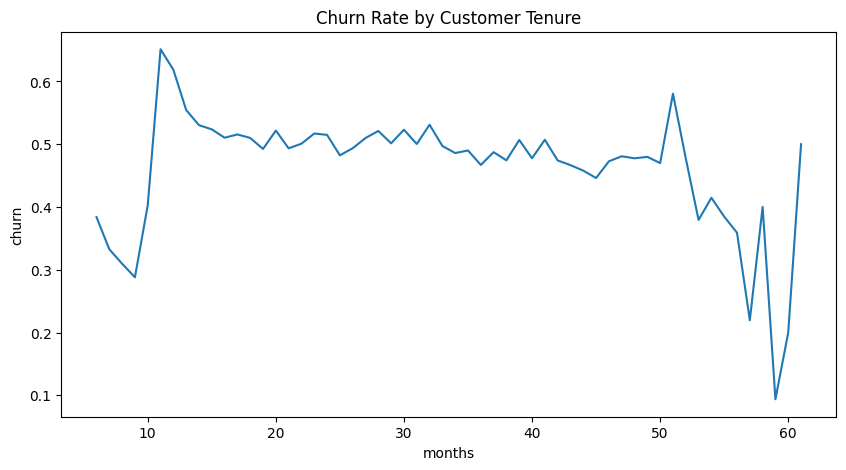

In [31]:
# Insight - Customer tenure vs revenue
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.lineplot(
    data=df.groupby('months')['churn'].mean().reset_index(),
    x='months',
    y='churn'
)
plt.title('Churn Rate by Customer Tenure')
plt.show()

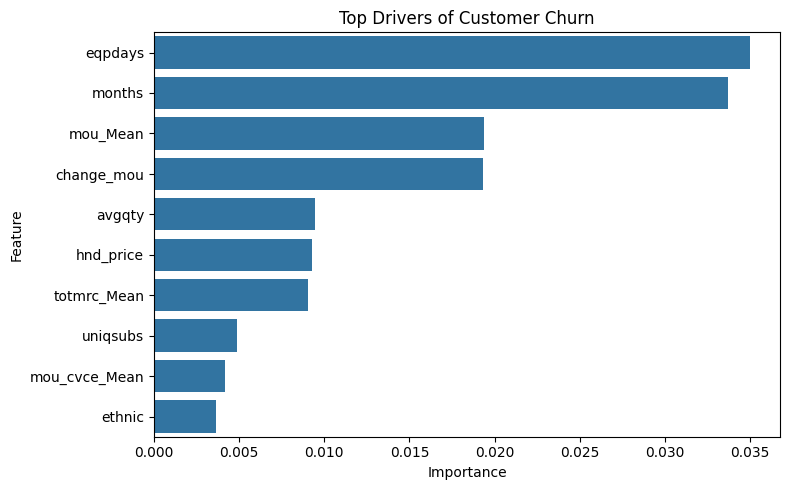

In [32]:
# Feature Importance chart
top10 = importance_df.head(10)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title("Top Drivers of Customer Churn")
plt.tight_layout()
plt.show()

/tmp/ipykernel_725/2587098016.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('eqp_bin')['churn'].mean().plot(


<Axes: xlabel='eqp_bin'>

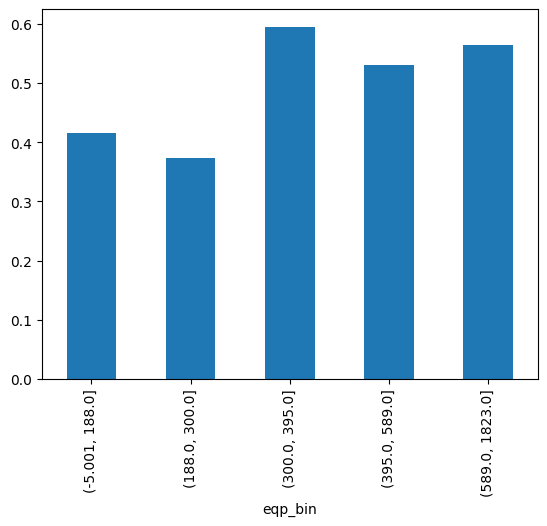

In [33]:
# Churn by device age
# Older devices = higher churn
df['eqp_bin'] = pd.qcut(df['eqpdays'], q=5)

df.groupby('eqp_bin')['churn'].mean().plot(
    kind='bar'
)

**Business Impact Quantification**

In [34]:
df['totrev'].mean()

np.float64(1031.9249883)

In [35]:
# Reduce churn by 5%
49562 * 0.05

2478.1000000000004

In [36]:
# Revenue preserved
2478 * 1031.92

2557097.7600000002

In [37]:
# Reduce churn by 10%
49562 * 0.10

4956.200000000001

In [38]:
# Revenue preserved
4956 * 1031.92

5114195.5200000005

In [39]:
# Reduce churn by 15%
49562 * 0.15

7434.299999999999

In [40]:
# Revenue preserved
7434 * 1031.92

7671293.28